In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.9 MB/s eta 0:00:00


In [3]:
pip install tensorflow

In [4]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import roc_auc_score

In [5]:
data = pd.read_csv(r'/content/Employee.csv')
data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


## Exploratory Data Analysis (EDA)

In [6]:
data.describe(include='all')

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
count,4653,4653.000000,4653,4653.000000,4653.000000,4653,4653,4653.000000,4653.000000
unique,3,NaN,3,NaN,NaN,2,2,NaN,NaN
top,Bachelors,NaN,Bangalore,NaN,NaN,Male,No,NaN,NaN
freq,3601,NaN,2228,NaN,NaN,2778,4175,NaN,NaN
mean,NaN,2015.062970,NaN,2.698259,29.393295,NaN,NaN,2.905652,0.343864
std,NaN,1.863377,NaN,0.561435,4.826087,NaN,NaN,1.558240,0.475047
min,NaN,2012.000000,NaN,1.000000,22.000000,NaN,NaN,0.000000,0.000000
25%,NaN,2013.000000,NaN,3.000000,26.000000,NaN,NaN,2.000000,0.000000
50%,NaN,2015.000000,NaN,3.000000,28.000000,NaN,NaN,3.000000,0.000000
75%,NaN,2017.000000,NaN,3.000000,32.000000,NaN,NaN,4.000000,1.000000


In [7]:
data.isnull().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


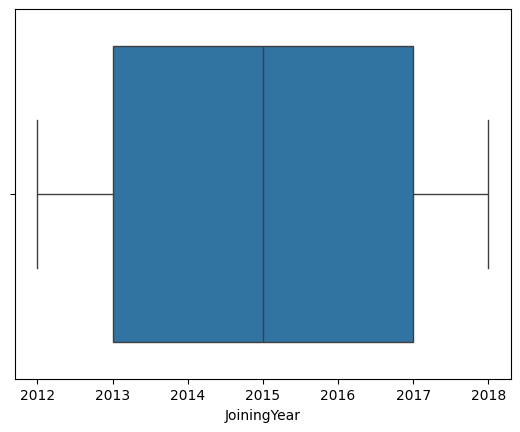

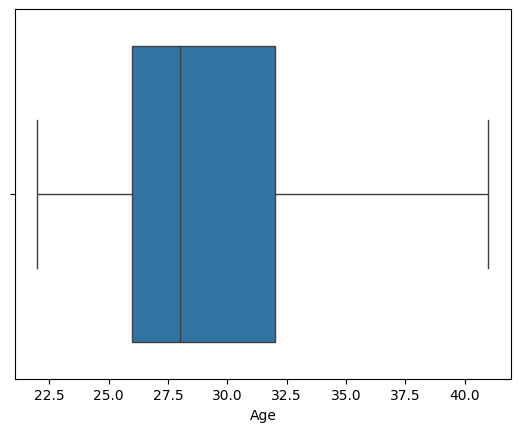

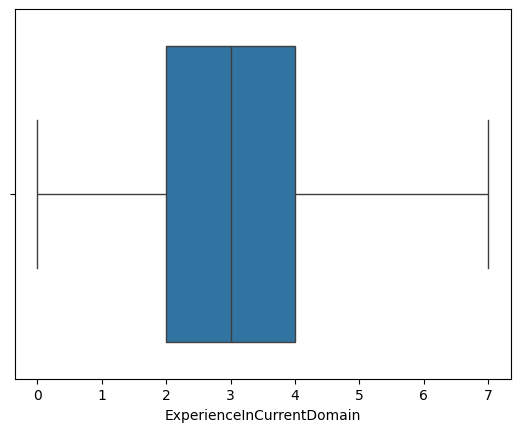

In [9]:
for i in data.columns:
  if data[i].dtype != object and i not in ['PaymentTier', 'LeaveOrNot']:
    sns.boxplot(data=data, x=data[i])
    plt.show()

## Encoding

In [10]:
data = pd.get_dummies(data, drop_first=True)

data

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,Education_Masters,Education_PHD,City_New Delhi,City_Pune,Gender_Male,EverBenched_Yes
0,2017,3,34,0,0,False,False,False,False,True,False
1,2013,1,28,3,1,False,False,False,True,False,False
2,2014,3,38,2,0,False,False,True,False,False,False
3,2016,3,27,5,1,True,False,False,False,True,False
4,2017,3,24,2,1,True,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
4648,2013,3,26,4,0,False,False,False,False,False,False
4649,2013,2,37,2,1,True,False,False,True,True,False
4650,2018,3,27,5,1,True,False,True,False,True,False
4651,2012,3,30,2,0,False,False,False,False,True,True


## Define Target & Features

In [11]:
targets = data['LeaveOrNot']

inputs = data.drop(['LeaveOrNot'],axis=1)

## Scaling

In [12]:
scaler = StandardScaler()
scaler.fit(inputs)

scaled = scaler.transform(inputs)

inputs_scaled = pd.DataFrame(scaled, columns=inputs.columns)

inputs_scaled

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,Education_Masters,Education_PHD,City_New Delhi,City_Pune,Gender_Male,EverBenched_Yes
0,1.039638,0.537503,0.954645,-1.864901,-0.480575,-0.200022,-0.575282,-0.612041,0.821551,-0.338365
1,-1.107233,-3.025177,-0.288732,0.060554,-0.480575,-0.200022,-0.575282,1.633878,-1.217210,-0.338365
2,-0.570515,0.537503,1.783563,-0.581264,-0.480575,-0.200022,1.738277,-0.612041,-1.217210,-0.338365
3,0.502921,0.537503,-0.495961,1.344191,2.080840,-0.200022,-0.575282,-0.612041,0.821551,-0.338365
4,1.039638,0.537503,-1.117650,-0.581264,2.080840,-0.200022,-0.575282,1.633878,0.821551,2.955387
...,...,...,...,...,...,...,...,...,...,...
4648,-1.107233,0.537503,-0.703191,0.702373,-0.480575,-0.200022,-0.575282,-0.612041,-1.217210,-0.338365
4649,-1.107233,-1.243837,1.576334,-0.581264,2.080840,-0.200022,-0.575282,1.633878,0.821551,-0.338365
4650,1.576356,0.537503,-0.495961,1.344191,2.080840,-0.200022,1.738277,-0.612041,0.821551,-0.338365
4651,-1.643951,0.537503,0.125727,-0.581264,-0.480575,-0.200022,-0.575282,-0.612041,0.821551,2.955387


## Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=42)

In [14]:
def create_model(trial):

    model = Sequential()


    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 32), activation='relu'))
    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 32), activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))


    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])

    return model

## Hyperparameter Tuning with Optuna

In [15]:
def optimal(trial):


    epochs = trial.suggest_int('epochs', 10, 50)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    model = create_model(trial)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)

    return auc

study = optuna.create_study(direction='maximize')
study.optimize(optimal, n_trials=15)

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-05-12 11:43:02,328] A new study created in memory with name: no-name-63437eb3-7082-485d-8cc0-5ba640cb17db
/tmp/ipykernel_23891/4260805968.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


Epoch 1/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.4630 - loss: 0.6924
Epoch 2/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.5340 - loss: 0.6559
Epoch 3/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.6019 - loss: 0.6354
Epoch 4/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6498 - loss: 0.6211
Epoch 5/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.6785 - loss: 0.6095
Epoch 6/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.6948 - loss: 0.6001
Epoch 7/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7046 - loss: 0.5920
Epoch 8/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7120 - loss: 0.5852
Epoch 9/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7178 - loss: 0.5794
Epoch 10/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7233 - loss: 0.5742
Epoch 11/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7270 - loss: 0.5698
Epoch 12/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7308 - loss: 0.5658
Epoch 13/43
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/st

[I 2026-05-12 11:43:19,987] Trial 0 finished with value: 0.8222971247638018 and parameters: {'epochs': 43, 'batch_size': 40, 'units_layer1': 9, 'units_layer2': 11, 'optimizer': 'adagrad', 'learning_rate': 0.005435837620848649}. Best is trial 0 with value: 0.8222971247638018.


Epoch 1/12


/tmp/ipykernel_23891/4260805968.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


...

Epoch 1/32


/tmp/ipykernel_23891/4260805968.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.6758 - loss: 0.6033
Epoch 2/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7790 - loss: 0.5137
Epoch 3/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8109 - loss: 0.4804
Epoch 4/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.8319 - loss: 0.4518
Epoch 5/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8439 - loss: 0.4335
Epoch 6/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.8535 - loss: 0.4184
Epoch 7/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.8577 - loss: 0.4068
Epoch 8/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8580 - loss: 0.4003
Epoch 9/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8642 - loss: 0.3908
Epoch 10/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8685 - loss: 0.3848
Epoch 11/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8719 - loss: 0.3801
Epoch 12/32
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8721 - loss: 0.3785
Epoch 13/32
162/162 ━━━━━━━━━━━━━━━━

[I 2026-05-12 11:46:00,324] Trial 14 finished with value: 0.8961135794903222 and parameters: {'epochs': 32, 'batch_size': 23, 'units_layer1': 15, 'units_layer2': 29, 'optimizer': 'adam', 'learning_rate': 0.0024031121417515283}. Best is trial 14 with value: 0.8961135794903222.


Best trial: 0.8961135794903222
Best hyperparameters: {'epochs': 32, 'batch_size': 23, 'units_layer1': 15, 'units_layer2': 29, 'optimizer': 'adam', 'learning_rate': 0.0024031121417515283}


## Build Best Model

In [16]:
best_params = study.best_trial.params

best_params

{'epochs': 32,
 'batch_size': 23,
 'units_layer1': 15,
 'units_layer2': 29,
 'optimizer': 'adam',
 'learning_rate': 0.0024031121417515283}

In [17]:
best_model = Sequential()
best_model.add(Dense(units=best_params['units_layer1'], activation='relu'))
best_model.add(Dense(units=best_params['units_layer2'], activation='relu'))
best_model.add(Dense(1, activation='sigmoid'))

In [18]:
if best_params['optimizer'] == 'adam':
    best_optimizer = Adam(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'sgd':
    best_optimizer = SGD(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'rmsprop':
    best_optimizer = RMSprop(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'adagrad':
    best_optimizer = Adagrad(learning_rate=best_params['learning_rate'])

## Compile Best Model

In [19]:
best_model.compile(optimizer=best_optimizer, loss='binary_crossentropy', metrics=['AUC'])

## Build Best Model

In [20]:
def evaluate(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train, epochs=23, batch_size=best_params['batch_size'])



    y_train_prob = model.predict(X_train)
    y_test_prob = model.predict(X_test)


    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1


    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1


    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],

    })

    return results

## Evaluate

In [21]:
evaluate(best_model, X_train, y_train, X_test, y_test)

Epoch 1/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7124 - loss: 0.5698
Epoch 2/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7887 - loss: 0.5063
Epoch 3/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.8095 - loss: 0.4791
Epoch 4/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8230 - loss: 0.4617
Epoch 5/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8325 - loss: 0.4468
Epoch 6/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8424 - loss: 0.4308
Epoch 7/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8490 - loss: 0.4210
Epoch 8/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8527 - loss: 0.4108
Epoch 9/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8554 - loss: 0.4032
Epoch 10/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8625 - loss: 0.3960
Epoch 11/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8655 - loss: 0.3916
Epoch 12/23
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.8668 - loss: 0.3853
Epoch 13/23
162/162 ━━━━━

,Dataset,Gini
0,Train,78.190275
1,Test,79.002605
